## RCoxNet vs baseline models — C-index comparison (Figure 4)

Reproduces Table 1 and Figure 4 from the paper.

Reads pre-computed per-repeat C-index results from `results/comparison_all_models.csv`,
which was generated by running `python scripts/run_benchmarks.py`.

Set `show_dots=True` in the last two cells to toggle jitter dots on the boxplot.

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
from scipy.stats import wilcoxon

ROOT = os.getcwd()

In [13]:
avail = {f.name for f in fm.fontManager.ttflist}
mpl.rcParams['font.sans-serif'] = ['Arial' if 'Arial' in avail else 'Liberation Sans']
mpl.rcParams['font.family']    = 'sans-serif'
mpl.rcParams['pdf.fonttype']   = 42
mpl.rcParams['ps.fonttype']    = 42
mpl.rcParams['font.size']         = 7
mpl.rcParams['axes.titlesize']    = 8
mpl.rcParams['axes.labelsize']    = 7
mpl.rcParams['xtick.labelsize']   = 7
mpl.rcParams['ytick.labelsize']   = 7
mpl.rcParams['legend.fontsize']   = 6.5
mpl.rcParams['axes.linewidth']    = 0.8
mpl.rcParams['xtick.major.width'] = 0.8
mpl.rcParams['ytick.major.width'] = 0.8
mpl.rcParams['xtick.major.size']  = 3
mpl.rcParams['ytick.major.size']  = 3

### Load results

In [14]:
df = pd.read_csv(os.path.join(ROOT, 'results', 'comparison_all_models.csv'))
print(df.shape)
df.head()

(480, 4)


,cancer,model,repeat,test_c_index
0,BRCA,Cox-EN,1,0.7816
1,BRCA,Cox-nnet,1,0.7835
2,BRCA,SurvivalNet,1,0.7370
3,BRCA,DeepSurv,1,0.7835
4,BRCA,DeepHit,1,0.6065


In [15]:
# 20 repeats per cancer per model
df.groupby(['cancer', 'model']).size().unstack().fillna(0).astype(int)

model,Cox-EN,Cox-nnet,DeepHit,DeepSurv,RCoxNet,SurvivalNet
cancer,,,,,,
BRCA,20,20,20,20,20,20
GBM,20,20,20,20,20,20
LUNG,20,20,20,20,20,20
OV,20,20,20,20,20,20


### Table 1 — mean ± std C-index

In [16]:
CANCERS     = ['BRCA', 'GBM', 'LUNG', 'OV']
MODEL_ORDER = ['RCoxNet', 'Cox-EN', 'Cox-nnet', 'SurvivalNet', 'DeepSurv', 'DeepHit']

smry = df.groupby(['cancer', 'model'])['test_c_index'].agg(['mean', 'std']).reset_index()
smry['val'] = smry.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)

tbl = smry.pivot(index='model', columns='cancer', values='val').reindex(index=MODEL_ORDER, columns=CANCERS)
print(tbl.to_string())

cancer                BRCA            GBM           LUNG             OV
model                                                                  
RCoxNet      0.807 ± 0.045  0.704 ± 0.042  0.750 ± 0.040  0.668 ± 0.037
Cox-EN       0.723 ± 0.074  0.646 ± 0.050  0.646 ± 0.040  0.630 ± 0.043
Cox-nnet     0.771 ± 0.039  0.658 ± 0.053  0.699 ± 0.047  0.657 ± 0.049
SurvivalNet  0.764 ± 0.045  0.646 ± 0.051  0.682 ± 0.043  0.631 ± 0.046
DeepSurv     0.782 ± 0.038  0.667 ± 0.050  0.722 ± 0.035  0.636 ± 0.067
DeepHit      0.625 ± 0.086  0.560 ± 0.081  0.616 ± 0.062  0.532 ± 0.048


In [17]:
# check results match paper Table 1
paper = {
    ('BRCA','RCoxNet'):(0.807,0.045), ('BRCA','Cox-EN'):(0.723,0.074),
    ('BRCA','Cox-nnet'):(0.771,0.039), ('BRCA','SurvivalNet'):(0.764,0.045),
    ('BRCA','DeepSurv'):(0.782,0.038), ('BRCA','DeepHit'):(0.625,0.086),
    ('GBM','RCoxNet'):(0.704,0.042),  ('GBM','Cox-EN'):(0.646,0.050),
    ('GBM','Cox-nnet'):(0.658,0.053), ('GBM','SurvivalNet'):(0.646,0.051),
    ('GBM','DeepSurv'):(0.667,0.050), ('GBM','DeepHit'):(0.560,0.081),
    ('LUNG','RCoxNet'):(0.750,0.040), ('LUNG','Cox-EN'):(0.646,0.040),
    ('LUNG','Cox-nnet'):(0.699,0.047),('LUNG','SurvivalNet'):(0.682,0.043),
    ('LUNG','DeepSurv'):(0.722,0.035),('LUNG','DeepHit'):(0.616,0.062),
    ('OV','RCoxNet'):(0.668,0.037),   ('OV','Cox-EN'):(0.630,0.043),
    ('OV','Cox-nnet'):(0.657,0.049),  ('OV','SurvivalNet'):(0.631,0.046),
    ('OV','DeepSurv'):(0.636,0.067),  ('OV','DeepHit'):(0.532,0.048),
}

ok = True
for (c, m), (em, es) in paper.items():
    row = smry[(smry.cancer == c) & (smry.model == m)]
    gm, gs = row['mean'].values[0], row['std'].values[0]
    if abs(gm - em) > 0.0015 or abs(gs - es) > 0.0015:
        print(f'MISMATCH {c}/{m}: got {gm:.3f}±{gs:.3f}  expected {em:.3f}±{es:.3f}')
        ok = False

if ok:
    print(f'All {len(paper)} values match paper Table 1.')

All 24 values match paper Table 1.


### Figure 4 — boxplot comparison with significance brackets

In [18]:
CANCER_LABELS = {
    'BRCA': 'Breast (BRCA)',
    'GBM':  'Glioblastoma (GBM)',
    'LUNG': 'Lung (LUNG)',
    'OV':   'Ovarian (OV)',
}

COLORS = {
    'Cox-EN':      '#7A9CB8',
    'Cox-nnet':    '#A88BBF',
    'SurvivalNet': '#C9A84C',
    'DeepSurv':    '#74A89E',
    'DeepHit':     '#B87060',
    'RCoxNet':     '#6A9E6E',
}

BASELINES = ['Cox-EN', 'Cox-nnet', 'SurvivalNet', 'DeepSurv', 'DeepHit']

In [19]:
def _sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def _draw_brackets(ax, pairs, top_y, dy=0.028, tip=0.010):
    # pairs sorted by span length so shorter brackets sit closer to the data
    for x1, x2, lbl in pairs:
        sig  = lbl != 'ns'
        col  = '#1a1a1a' if sig else '#999999'
        h    = top_y + tip
        ax.plot([x1, x1, x2, x2],
                [h, h + dy*0.45, h + dy*0.45, h],
                lw=0.9 if sig else 0.7, color=col,
                linestyle='-' if sig else '--',
                clip_on=False, zorder=6, solid_capstyle='round')
        ax.text((x1+x2)/2, h + dy*0.45 + 0.005, lbl,
                ha='center', va='bottom',
                fontsize=6.5 if sig else 5.5,
                fontweight='bold' if sig else 'normal',
                fontstyle='normal' if sig else 'italic',
                color=col, clip_on=False)
        top_y += dy


def plot_figure4(data, show_dots=True):
    models = [m for m in ['Cox-EN','Cox-nnet','SurvivalNet','DeepSurv','DeepHit','RCoxNet']
              if m in data['model'].unique()]

    # sort by median C-index so the best model ends up on the right
    models = sorted(models, key=lambda m: np.median(data[data.model==m]['test_c_index'].values))

    n   = len(models)
    ylo = max(0.35, data['test_c_index'].min() - 0.06)
    yhi = min(1.02, data['test_c_index'].max() + 0.06 + 5*0.038)

    fig, axes = plt.subplots(1, 4, figsize=(7.09, 4.4), dpi=150, sharey=True)
    fig.subplots_adjust(wspace=0.06, left=0.10, right=0.985, top=0.76, bottom=0.22)

    for ci, (ax, cancer) in enumerate(zip(axes, CANCERS)):
        vals   = [data[(data.cancer==cancer) & (data.model==m)]['test_c_index'].values
                  for m in models]
        colors = [COLORS[m] for m in models]

        ax.axhline(0.5, color='#cccccc', lw=0.6, linestyle=':', zorder=1)

        bp = ax.boxplot(vals, patch_artist=True, widths=0.52,
                        medianprops=dict(color='#111111', linewidth=1.4, zorder=5),
                        whiskerprops=dict(color='#606060', linewidth=0.75),
                        capprops=dict(color='#606060', linewidth=0.75),
                        flierprops=dict(marker='o', markersize=1.8,
                                        markerfacecolor='#aaaaaa',
                                        markeredgewidth=0, alpha=0.6),
                        showfliers=True, zorder=2)

        for box, col in zip(bp['boxes'], colors):
            box.set_facecolor(col)
            box.set_alpha(0.85)
            box.set_linewidth(0.5)
            box.set_edgecolor('#555555')

        ri = models.index('RCoxNet')
        bp['boxes'][ri].set_edgecolor('#2e5e32')
        bp['boxes'][ri].set_linewidth(0.9)

        if show_dots:
            np.random.seed(42)
            for i, (d, col) in enumerate(zip(vals, colors)):
                jx = np.random.uniform(-0.15, 0.15, len(d))
                ax.scatter(i+1+jx, d, color=col, s=4.5, alpha=0.40,
                           edgecolors='none', zorder=3)

        # Wilcoxon one-sided test: RCoxNet vs each baseline
        rcox_v   = vals[ri]
        top_data = max(v.max() for v in vals if len(v))
        pairs = []
        for bl in BASELINES:
            if bl not in models: continue
            bi = models.index(bl)
            try:
                _, p = wilcoxon(rcox_v, vals[bi], alternative='greater')
            except Exception:
                p = 1.0
            pairs.append((bi+1, ri+1, _sig(p), abs(ri-bi)))
        pairs.sort(key=lambda x: x[3])
        _draw_brackets(ax, [(a,b,l) for a,b,l,_ in pairs], top_y=top_data)

        ax.set_title(CANCER_LABELS[cancer], fontsize=7.5, fontweight='bold', pad=5)
        ax.set_xticks(range(1, n+1))
        ax.set_xticklabels(models, rotation=40, ha='right',
                           fontsize=6.5, rotation_mode='anchor')
        ax.set_ylim(ylo, yhi)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.10))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
        ax.tick_params(axis='y', which='minor', length=2, width=0.5)
        ax.tick_params(axis='both', which='major', width=0.8, length=3, pad=2)

        if ci == 0:
            ax.set_ylabel('C-index', fontsize=7, labelpad=4)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if ci > 0:
            ax.spines['left'].set_visible(False)
            ax.tick_params(axis='y', which='both', left=False)
        ax.grid(False)

    handles = [mpatches.Patch(facecolor=COLORS[m], edgecolor='none', label=m)
               for m in models]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.54, -0.02),
               ncol=n, frameon=False, handlelength=0.9, handleheight=0.7,
               columnspacing=0.8, handletextpad=0.4, borderpad=0, fontsize=6.5)
    return fig

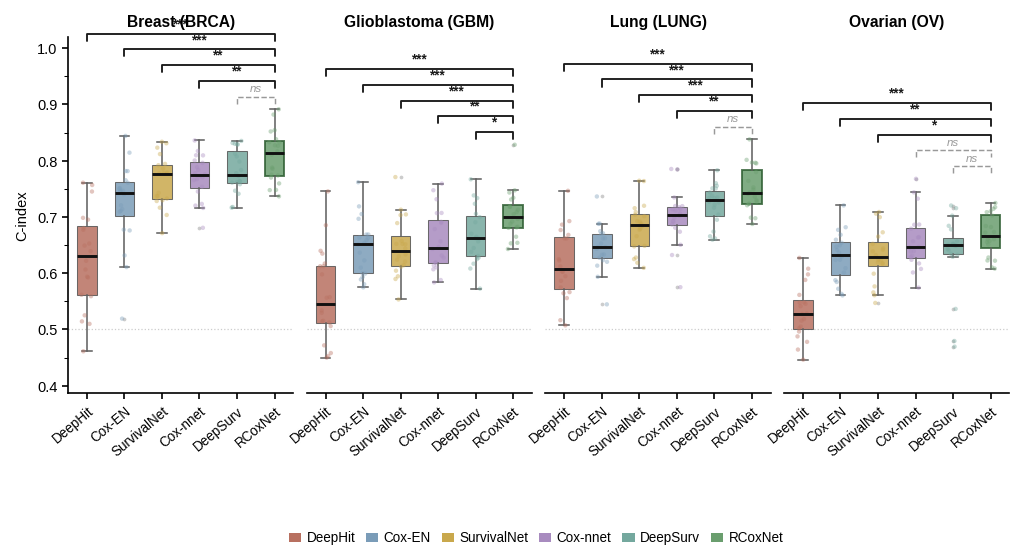

In [20]:
fig = plot_figure4(df, show_dots=True)
fig.savefig(os.path.join(ROOT, 'results', 'Figure4_comparison.pdf'),
            bbox_inches='tight', format='pdf')
plt.show()

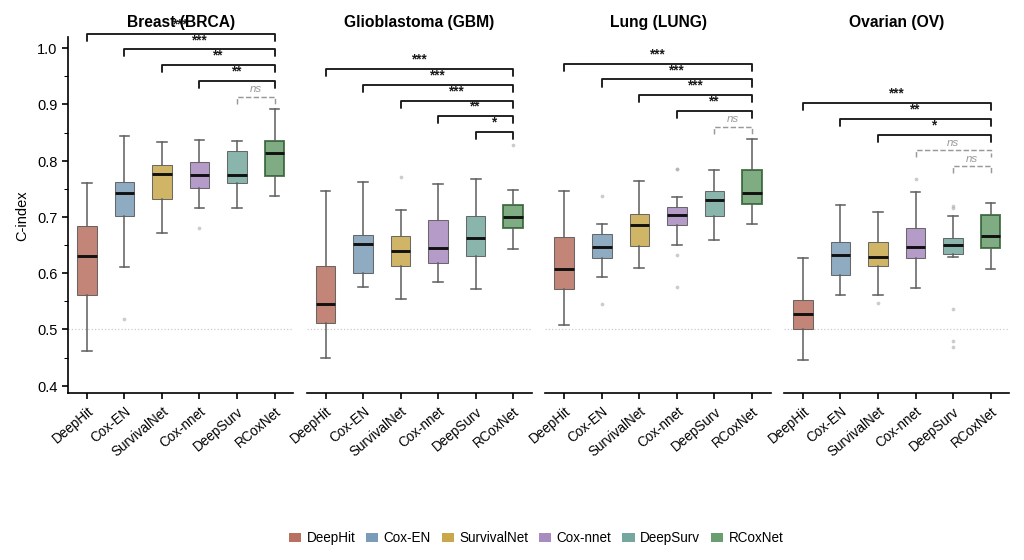

In [21]:
fig2 = plot_figure4(df, show_dots=False)
fig2.savefig(os.path.join(ROOT, 'results', 'Figure4_comparison_no_dots.pdf'),
            bbox_inches='tight', format='pdf')
plt.show()

### Per-repeat raw numbers

In [22]:
pd.set_option('display.max_rows', 100)
pivot = (
    df
    .assign(model=pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True))
    .sort_values(['cancer', 'model', 'repeat'])
    .pivot_table(index=['cancer','repeat'], columns='model', values='test_c_index')
    .round(4)
)
pivot

/tmp/ipykernel_3241995/1643972490.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df


model          RCoxNet  Cox-EN  Cox-nnet  SurvivalNet  DeepSurv  DeepHit
cancer repeat                                                           
BRCA   1        0.8329  0.7816    0.7835       0.7370    0.7835   0.6065
       2        0.8382  0.7465    0.7672       0.8337    0.7730   0.7452
       3        0.7856  0.5192    0.7160       0.7283    0.7466   0.5099
       4        0.8542  0.7465    0.8173       0.7768    0.7610   0.5924
       5        0.7596  0.7404    0.7887       0.7772    0.8300   0.6984
       6        0.8108  0.7815    0.7730       0.7776    0.8125   0.7609
       7        0.8820  0.7206    0.7202       0.7165    0.7640   0.5143
       8        0.8166  0.6316    0.6807       0.6712    0.7412   0.5591
       9        0.7750  0.8441    0.8360       0.7297    0.8352   0.6952
       10       0.7477  0.7501    0.7759       0.7919    0.8076   0.6527
       11       0.7878  0.7652    0.7704       0.7788    0.7177   0.5616
       12       0.8520  0.7108    0.8097       0.7943    0.7985   0.7568
       13       0.8326  0.7090    0.7655       0.7327    0.7582   0.6391
       14       0.8263  0.8143    0.8095       0.8310    0.8286   0.6802
       15       0.7481  0.6760    0.7232       0.7860    0.7630   0.4611
       16       0.8914  0.7607    0.7537       0.7035    0.7619   0.6771
       17       0.7738  0.7138    0.7962       0.8232    0.8296   0.5251
       18       0.7701  0.7514    0.8004       0.7430    0.7778   0.5937
       19       0.7366  0.6108    0.7452       0.7373    0.7166   0.6220
       20       0.8274  0.6774    0.7778       0.8118    0.8315   0.6491
GBM    1        0.6430  0.6228    0.7068       0.6521    0.6997   0.4717
       2        0.7473  0.7188    0.6189       0.7033    0.6251   0.5059
       3        0.7310  0.6098    0.7593       0.7709    0.7383   0.4528
       4        0.7341  0.7051    0.7315       0.6439    0.7669   0.5563
       5        0.6964  0.5932    0.6188       0.5945    0.6169   0.5338
       6        0.6880  0.6687    0.6468       0.6521    0.6448   0.5295
       7        0.6918  0.6365    0.5836       0.5533    0.6566   0.6398
       8        0.6648  0.5748    0.7071       0.7129    0.7335   0.5574
       9        0.7181  0.5805    0.6069       0.6115    0.5726   0.4499
       10       0.6806  0.6512    0.6276       0.6238    0.6906   0.7454
       11       0.6531  0.6536    0.6894       0.7045    0.6701   0.6123
       12       0.7434  0.6634    0.6785       0.6142    0.6306   0.4580
       13       0.7128  0.7617    0.6431       0.6334    0.6276   0.5123
       14       0.7087  0.6628    0.6314       0.6205    0.6648   0.6348
       15       0.8284  0.6688    0.6567       0.6574    0.6618   0.5142
       16       0.6540  0.6589    0.5878       0.6514    0.6621   0.5979
       17       0.6814  0.5888    0.6913       0.6044    0.7056   0.6123
       18       0.7180  0.6967    0.7475       0.6891    0.7234   0.6853
       19       0.6827  0.5993    0.6103       0.5897    0.6083   0.6172
       20       0.7049  0.6000    0.6140       0.6300    0.6380   0.5153
LUNG   1        0.8015  0.6709    0.7112       0.7038    0.7042   0.6024
       2        0.7525  0.5936    0.7346       0.7644    0.7507   0.6926
       3        0.7434  0.6274    0.6505       0.6250    0.6596   0.5557
       4        0.7968  0.6747    0.7194       0.7638    0.7342   0.5072
       5        0.7297  0.6696    0.6987       0.6658    0.7378   0.6120
       6        0.7232  0.6623    0.7845       0.6882    0.7509   0.5164
       7        0.6987  0.6877    0.6922       0.6926    0.6950   0.6225
       8        0.7359  0.6327    0.7142       0.6773    0.7599   0.6681
       9        0.7234  0.6619    0.6864       0.6915    0.7258   0.5946
       10       0.7208  0.6434    0.7192       0.7086    0.7164   0.6618
       11       0.8379  0.6231    0.6737       0.6486    0.6656   0.6251
       12       0.7410  0.6466    0.6920       0.6841    0.7553   0.5663
       13       0.7273  0.7364    0.7853       0.7014    0